_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Bach Nguyen, Yuzhe Han

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 3

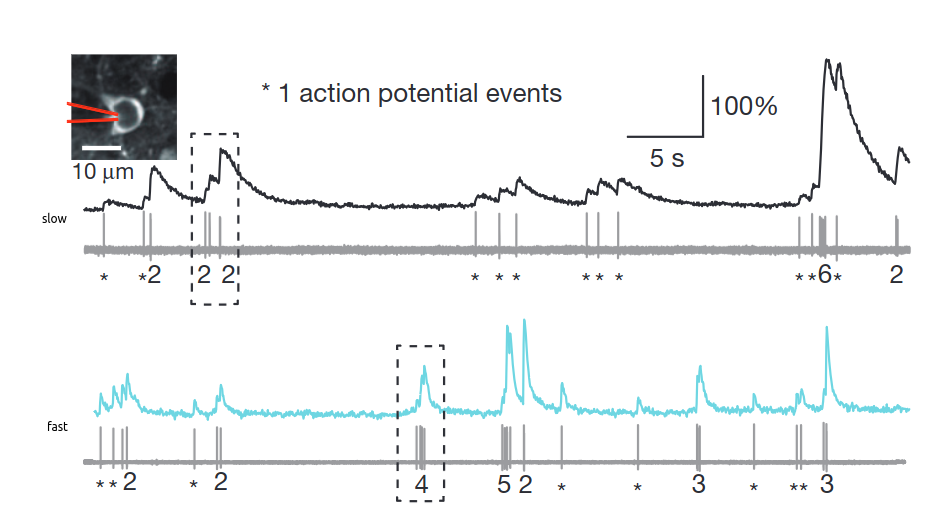

In this notebook you will work with 2 photon calcium recordings from mouse V1 and retina. For details see [Chen et al. 2013](https://www.nature.com/articles/nature12354) and [Theis et al. 2016](https://www.cell.com/neuron/pdf/S0896-6273(16)30073-3.pdf). Two-photon imaging is widely used to study computations in populations of neurons. 

In this exercise sheet we will study properties of different indicators and work on methods to infer spikes from calcium traces. All data is provided at a sampling rate of 100 Hz. For easier analysis, please resample it to 25 Hz. `scipy.signal.decimate` can help here, but note that it is only meant for continous signals. 

__Data__: Download the data file ```nds_cl_3_*.csv``` from ILIAS and save it in a subfolder ```../data/```. Note, some recordings were of shorter duration, hence their columns are padded. 

In [ ]:
from __future__ import annotations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-05-10 21:24:29 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
pandas    : 2.3.3
scipy     : 1.15.3
seaborn   : 0.13.2

Watermark: 2.6.0



In [ ]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [ ]:
# ogb dataset from Theis et al. 2016 Neuron
ogb_calcium = pd.read_csv("../data/nds_cl_3_ogb_calcium.csv", header=0)
ogb_spikes = pd.read_csv("../data/nds_cl_3_ogb_spikes.csv", header=0)
print(f"[OGB] calcium: {ogb_calcium.shape}, spikes: {ogb_spikes.shape}")

# gcamp dataset from Chen et al. 2013 Nature
gcamp_calcium = pd.read_csv("../data/nds_cl_3_gcamp2_calcium.csv", header=0)
gcamp_spikes = pd.read_csv("../data/nds_cl_3_gcamp2_spikes.csv", header=0)
print(f"[GCaMP] calcium: {gcamp_calcium.shape}, spikes: {gcamp_spikes.shape}")

# spike dataframe
ogb_spikes.head()

[OGB] calcium: (71986, 11), spikes: (71986, 11)
[GCaMP] calcium: (23973, 37), spikes: (23973, 37)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
1,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
2,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
3,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
4,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0


## Task 1: Visualization of calcium and spike recordings

We start again by plotting the raw data - calcium and spike traces in this case. One dataset has been recorded using the synthetic calcium indicator OGB-1 at population imaging zoom (~100 cells in a field of view) and the other one using the genetically encoded indicator GCamp6f zooming in on individual cells. Plot the traces of an example cell from each dataset to show how spikes and calcium signals are related. A good example cell for the OGB-dataset is cell 5. For the CGamp-dataset a good example is cell 6. Align the traces by eye (add a small offset to the plot) such that a valid comparison is possible and zoom in on a small segment of tens of seconds.

*Grading: 3 pts*

Text(0.5, 0, 'Time [s]')

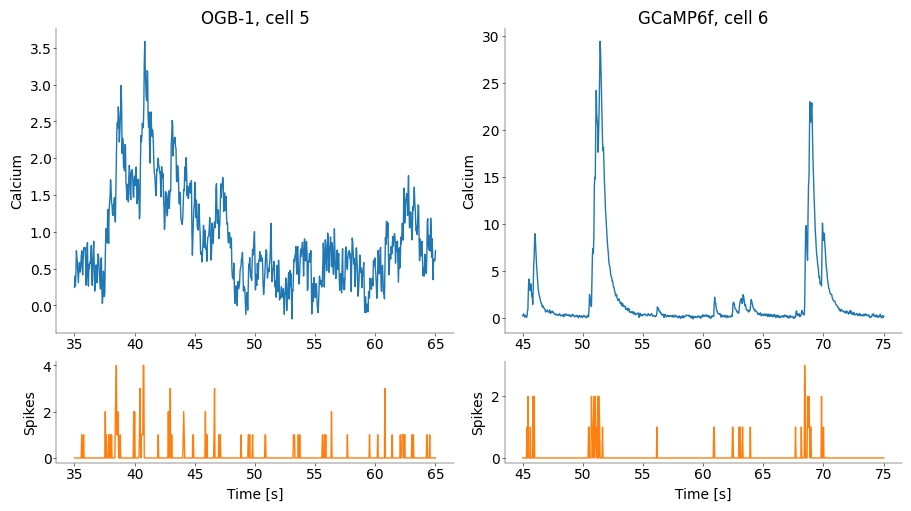

In [ ]:
# --------------------------------
# Resample and prepare data (1 pt)
# --------------------------------
factor = 4
fs = 25
dt = 1 / fs


def prepare_trace_pair(calcium_df, spikes_df, cell, factor=4):
    ca = signal.decimate(calcium_df.iloc[:, cell].dropna().to_numpy(), factor)

    sp = spikes_df.iloc[:, cell].dropna().to_numpy()
    sp = sp[: len(sp) // factor * factor].reshape(-1, factor).sum(axis=1)

    n = min(len(ca), len(sp))
    ca = ca[:n]
    sp = sp[:n]
    t = np.arange(n) * dt

    return t, ca, sp


t_ogb, ogb_calcium_5, ogb_spikes_5 = prepare_trace_pair(ogb_calcium, ogb_spikes, cell=5)
t_gcamp, gcamp_calcium_6, gcamp_spikes_6 = prepare_trace_pair(
    gcamp_calcium, gcamp_spikes, cell=6
)


fig, axs = plt.subplots(
    2, 2, figsize=(9, 5), height_ratios=[3, 1], layout="constrained"
)

# --------------------
# Plot OGB data (1 pt)
# --------------------
start, stop = 35, 65
mask = (t_ogb >= start) & (t_ogb <= stop)

axs[0, 0].plot(t_ogb[mask], ogb_calcium_5[mask], color="C0")
axs[1, 0].plot(t_ogb[mask], ogb_spikes_5[mask], color="C1")

axs[0, 0].set_title("OGB-1, cell 5")
axs[0, 0].set_ylabel("Calcium")
axs[1, 0].set_ylabel("Spikes")
axs[1, 0].set_xlabel("Time [s]")

# ----------------------
# Plot GCamp data (1 pt)
# ----------------------
start, stop = 45, 75
mask = (t_gcamp >= start) & (t_gcamp <= stop)

axs[0, 1].plot(t_gcamp[mask], gcamp_calcium_6[mask], color="C0")
axs[1, 1].plot(t_gcamp[mask], gcamp_spikes_6[mask], color="C1")

axs[0, 1].set_title("GCaMP6f, cell 6")
axs[0, 1].set_ylabel("Calcium")
axs[1, 1].set_ylabel("Spikes")
axs[1, 1].set_xlabel("Time [s]")

## Bonus Task (Optional): Calcium preprocessing

To improve the quality of the inferred spikes, further preprocessing steps can undertaken. This includes filtering and smoothing of the calcium trace.

Implement a suitable filter and local averaging procedure as discussed in the lecture. Explain your choices and discuss how it helps!

_Grading: 1 BONUS point_

_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

## Task 2: Simple deconvolution

It is clear from the above plots that the calcium events happen in relationship to the spikes. As a first simple algorithm implement a deconvolution approach like presented in the lecture in the function `deconv_ca`. Assume an exponential kernel where the decay constant depends on the indicator ($\tau_{OGB}= 0.5 s$, $\tau_{GCaMP}= 0.1 s$). Note there can be no negative rates! Plot the kernel as well as an example cell with true and deconvolved spike rates. Scale the signals such as to facilitate comparisons. You can use functions from `scipy` for this. Explain your results and your choice of kernel.

*Grading: 5 pts*


In [ ]:
def deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply deconvolution to calcium signal (1 pt)
    # --------------------------------------------
    kernel_length = int(5 * tau / dt)  # sufficiently long for convergence
    kernel = np.exp(-np.arange(kernel_length) * dt / tau)  # exp(-t/tau)
    kernel = kernel / kernel.sum()

    # pad the calcium signal to avoid edge effects during deconvolution
    pad_width = len(kernel) - 1
    ca_padded = np.pad(ca, (0, pad_width), mode="edge")

    sp_hat = np.maximum(
        signal.deconvolve(ca_padded, kernel)[0], 0
    )  # remove negative values

    return np.asarray(sp_hat)

<matplotlib.legend.Legend>

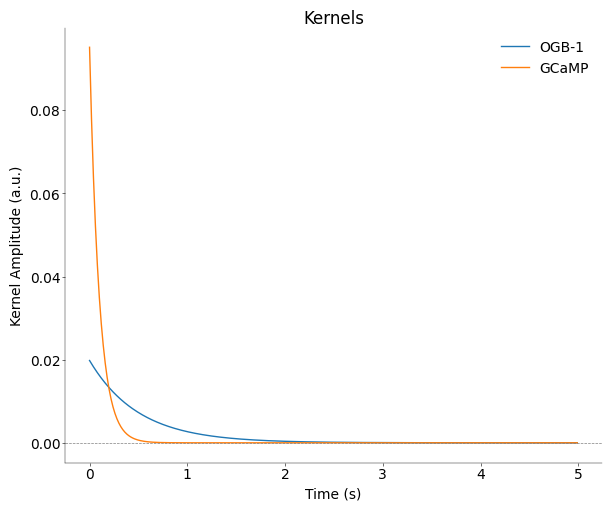

In [ ]:
# -------------------------
# Plot the 2 kernels (1 pt)
# -------------------------
plt.figure(figsize=(6, 5), layout="constrained")
tau_ogb = 0.5
tau_gcamp = 0.1

t = np.arange(0, 5, 0.01)
kernel_ogb = np.exp(-t / tau_ogb)
kernel_ogb = kernel_ogb / kernel_ogb.sum()
kernel_gcamp = np.exp(-t / tau_gcamp)
kernel_gcamp = kernel_gcamp / kernel_gcamp.sum()
plt.plot(t, kernel_ogb, label="OGB-1", color="C0")
plt.plot(t, kernel_gcamp, label="GCaMP", color="C1")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Kernel Amplitude (a.u.)")
plt.title("Kernels")
plt.legend()

### Questions (1 pt)
1) Explain how you constructed the kernels

A simple exponential kernel that follows $\exp(- t/\tau)$, with different $\tau$ for OGB-1 and GCaMP.

2) How do the indicators / kernels compare?

As $\tau_{GCaMP}= 0.1 s < \tau_{OGB}= 0.5 s$, the kernel of GCaMP is more abrupt than OGB-1, and spend less time converging to zero.

3) What are pros and cons of each indicator?

- GCaMP: 
    - (+) higher signal-to-noise, faster kinetics, less phototoxic
    - (-) time-consuming for genetic encoding process (e.g., transgenic animals or viral transfection), relys on the expression level of individual cells that vary
- OGB-1:
    - (+) easy to implement with membrane-permeable dyes. 
    - (-) lower signal-to-noise due to background noise, lower kinetics, more phototoxic

(<Figure size 700x500 with 3 Axes>,
 array([<Axes: title={'center': 'GCaMP6f, cell 6'}, ylabel='Calcium'>,
        <Axes: ylabel='True spikes'>,
        <Axes: xlabel='Time [s]', ylabel='Deconv.'>], dtype=object))

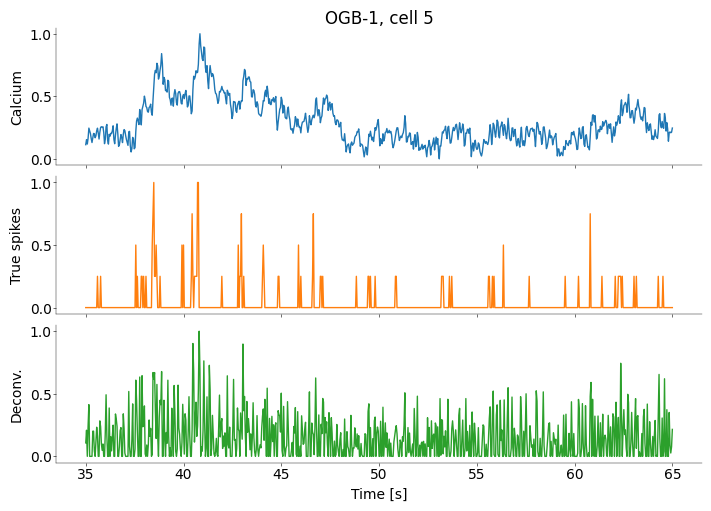

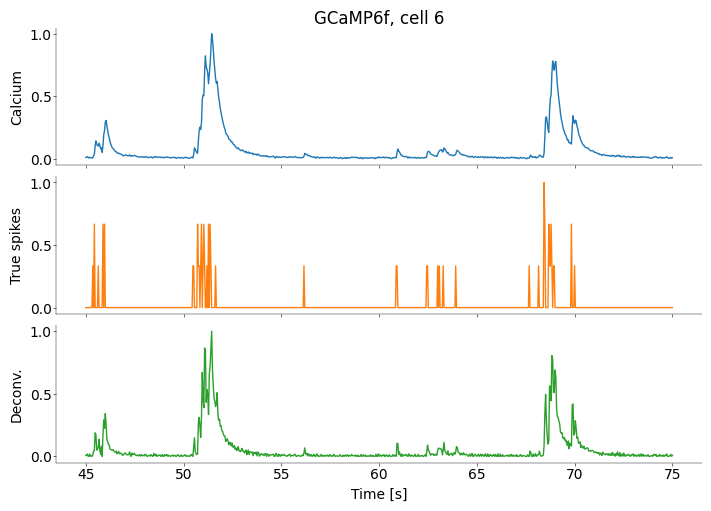

In [ ]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spike rates for the OGB and GCamP cells.
# What differences do you notice? Does this align with your knowledge
# about the indicators? (2 pts)
# ----------------------------------------------------------------------


def normalize(x):
    x = np.asarray(x)
    if np.nanmax(x) == np.nanmin(x):
        return x
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))


def plot_deconv_comparison(t, ca, sp, tau, title, start, stop):
    sp_hat = deconv_ca(ca, tau=tau, dt=dt)

    n = min(len(t), len(ca), len(sp), len(sp_hat))
    t = t[:n]
    ca = ca[:n]
    sp = sp[:n]
    sp_hat = sp_hat[:n]

    true_rate = sp / dt

    mask = (t >= start) & (t <= stop)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(7, 5),
        height_ratios=[1, 1, 1],
        gridspec_kw=dict(hspace=0),
        sharex=True,
    )

    axs[0].plot(t[mask], normalize(ca[mask]), color="C0")
    axs[0].set_ylabel("Calcium")
    axs[0].set_title(title)

    axs[1].plot(t[mask], normalize(true_rate[mask]), color="C1")
    axs[1].set_ylabel("True spikes")

    axs[2].plot(t[mask], normalize(sp_hat[mask]), color="C2")
    axs[2].set_ylabel("Deconv.")
    axs[2].set_xlabel("Time [s]")

    return fig, axs


# OGB Cell
plot_deconv_comparison(
    t_ogb,
    ogb_calcium_5,
    ogb_spikes_5,
    tau=0.5,
    title="OGB-1, cell 5",
    start=35,
    stop=65,
)

# GCaMP Cell
plot_deconv_comparison(
    t_gcamp,
    gcamp_calcium_6,
    gcamp_spikes_6,
    tau=0.1,
    title="GCaMP6f, cell 6",
    start=45,
    stop=75,
)

*What differences do you notice? Does this align with your knowledge about the indicators?*

The deconvolved spike rates generally follow the true spike rates, but the amplitudes do not match perfectly. Furthermore, GCaMP shows a slightly clearer alignment than OGB-1 due to its higher single-cell resolution.

## Task 3: Run more complex algorithm

As reviewed in the lecture, a number of more complex algorithms for inferring spikes from calcium traces have been developed. Run an implemented algorithm on the data and plot the result. There is a choice of algorithms available, for example:

* Vogelstein: [oopsi](https://github.com/liubenyuan/py-oopsi)
* Theis: [c2s](https://github.com/lucastheis/c2s)
* Friedrich: [OASIS](https://github.com/j-friedrich/OASIS)

*Grading: 3 pts*



### 1. oopsi

In [ ]:
# run this cell to download the oopsi.py file and put it in the same folder as this notebook
# !wget https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
# !curl -O https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py  # for Mac
import oopsi

# Note: `from scipy.sparse.linalg.dsolve import linsolve` should be replaved by `from scipy.sparse.linalg import spsolve`. The same to `linsolve.spsolve` -> `spsolve`

In [ ]:
# ----------------------------------------------------------------------
# Apply one of the advanced algorithms to the OGB and GCamp Cells (1 pt)
# ----------------------------------------------------------------------

ogb_spikes_oopsi, _ = oopsi.fast(ogb_calcium_5, dt=dt, iter_max=6)
gcamp_spikes_oopsi, _ = oopsi.fast(gcamp_calcium_6, dt=dt, iter_max=6)

(<Figure size 700x500 with 3 Axes>,
 array([<Axes: title={'center': 'GCaMP6f, cell 6'}, ylabel='Calcium'>,
        <Axes: ylabel='True spikes'>,
        <Axes: xlabel='Time [s]', ylabel='Oppsi'>], dtype=object))

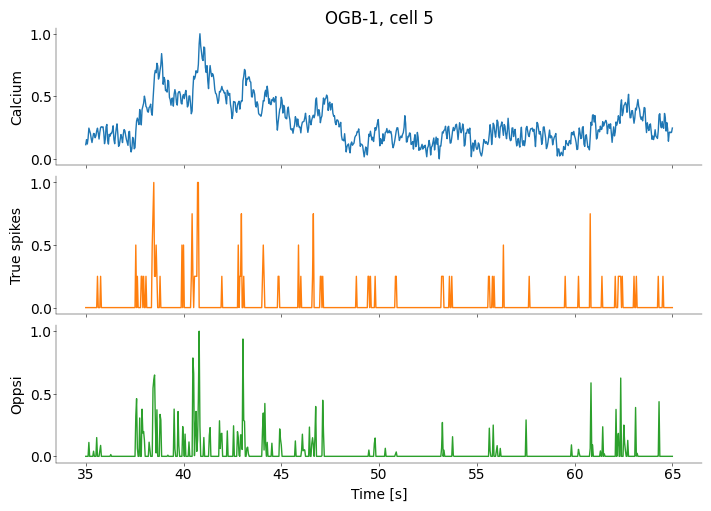

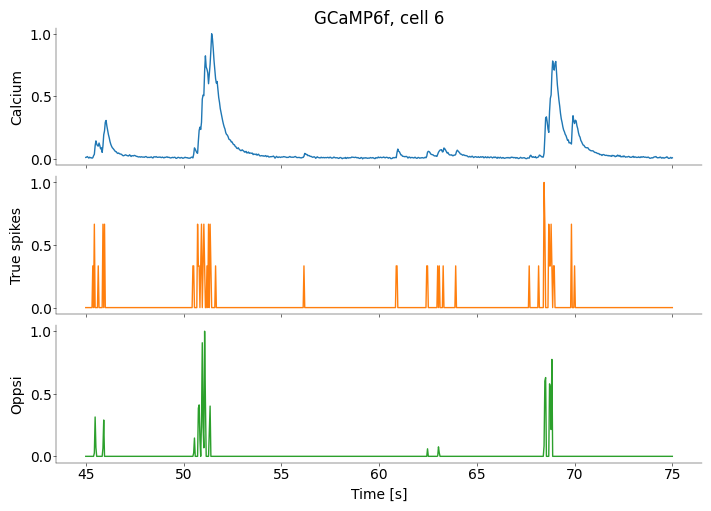

In [ ]:
# -------------------------------------------------------------------------------
# Plot the results for the OGB and GCamp Cells and describe the results (1+1 pts)
# -------------------------------------------------------------------------------


def plot_oppsi_result(t, ca, true_sp, oasis_sp, title, start, stop):
    n = min(len(t), len(ca), len(true_sp), len(oasis_sp))
    t = t[:n]
    ca = ca[:n]
    true_sp = true_sp[:n]
    oasis_sp = oasis_sp[:n]

    mask = (t >= start) & (t <= stop)
    true_rate = true_sp / dt

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(7, 5),
        height_ratios=[1, 1, 1],
        gridspec_kw=dict(hspace=0),
        sharex=True,
    )

    axs[0].plot(t[mask], normalize(ca[mask]), color="C0")
    axs[0].set_ylabel("Calcium")
    axs[0].set_title(title)

    axs[1].plot(t[mask], normalize(true_rate[mask]), color="C1")
    axs[1].set_ylabel("True spikes")

    axs[2].plot(t[mask], normalize(oasis_sp[mask]), color="C2")
    axs[2].set_ylabel("Oppsi")
    axs[2].set_xlabel("Time [s]")

    return fig, axs


plot_oppsi_result(
    t_ogb,
    ogb_calcium_5,
    ogb_spikes_5,
    ogb_spikes_oopsi,
    title="OGB-1, cell 5",
    start=35,
    stop=65,
)

plot_oppsi_result(
    t_gcamp,
    gcamp_calcium_6,
    gcamp_spikes_6,
    gcamp_spikes_oopsi,
    title="GCaMP6f, cell 6",
    start=45,
    stop=75,
)

### 2 OASIS

In [ ]:
from oasis.functions import deconvolve as oasis_deconvolve

/Users/eastos/miniforge3/envs/nds_env/lib/python3.10/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [ ]:
# ----------------------------------------------------------------------
# Apply OASIS to the OGB and GCaMP cells
# ----------------------------------------------------------------------


def run_oasis(ca: np.ndarray, tau: float, dt: float):
    y = np.asarray(ca, dtype=np.float64)

    # Discrete AR(1) decay coefficient:
    # c[t] = gamma * c[t-1] + s[t]
    gamma = np.exp(-dt / tau)

    c, s, b, g, lam = oasis_deconvolve(
        y,
        g=(gamma,),
        penalty=1,
        b_nonneg=False,
    )

    s = np.clip(s, 0, None)

    return c, s


ogb_oasis_ca, ogb_oasis_sp = run_oasis(ogb_calcium_5, tau=0.5, dt=dt)
gcamp_oasis_ca, gcamp_oasis_sp = run_oasis(gcamp_calcium_6, tau=0.1, dt=dt)

/Users/eastos/miniforge3/envs/nds_env/lib/python3.10/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


(<Figure size 700x500 with 3 Axes>,
 array([<Axes: title={'center': 'GCaMP6f, cell 6'}, ylabel='Calcium'>,
        <Axes: ylabel='True spikes'>,
        <Axes: xlabel='Time [s]', ylabel='OASIS'>], dtype=object))

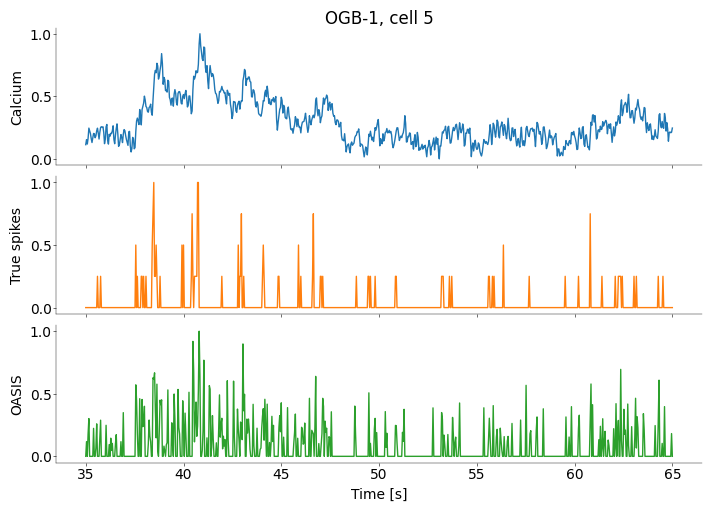

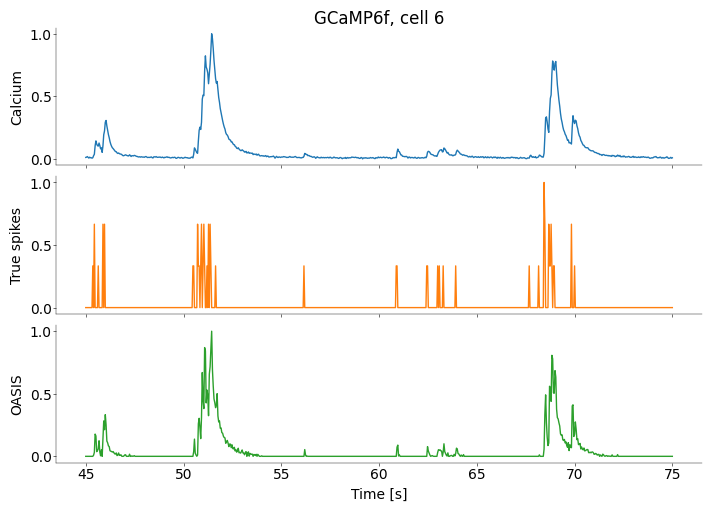

In [ ]:
# -------------------------------------------------------------------------------
# Plot the results for the OGB and GCaMP cells
# -------------------------------------------------------------------------------


def plot_oasis_result(t, ca, true_sp, oasis_sp, title, start, stop):
    n = min(len(t), len(ca), len(true_sp), len(oasis_sp))
    t = t[:n]
    ca = ca[:n]
    true_sp = true_sp[:n]
    oasis_sp = oasis_sp[:n]

    mask = (t >= start) & (t <= stop)
    true_rate = true_sp / dt

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(7, 5),
        height_ratios=[1, 1, 1],
        gridspec_kw=dict(hspace=0),
        sharex=True,
    )

    axs[0].plot(t[mask], normalize(ca[mask]), color="C0")
    axs[0].set_ylabel("Calcium")
    axs[0].set_title(title)

    axs[1].plot(t[mask], normalize(true_rate[mask]), color="C1")
    axs[1].set_ylabel("True spikes")

    axs[2].plot(t[mask], normalize(oasis_sp[mask]), color="C2")
    axs[2].set_ylabel("OASIS")
    axs[2].set_xlabel("Time [s]")

    return fig, axs


plot_oasis_result(
    t_ogb,
    ogb_calcium_5,
    ogb_spikes_5,
    ogb_oasis_sp,
    title="OGB-1, cell 5",
    start=35,
    stop=65,
)

plot_oasis_result(
    t_gcamp,
    gcamp_calcium_6,
    gcamp_spikes_6,
    gcamp_oasis_sp,
    title="GCaMP6f, cell 6",
    start=45,
    stop=75,
)

## Task 4: Evaluation of algorithms

To formally evaluate the algorithms on the two datasets run the deconvolution algorithm and the more complex one on all cells and compute the correlation between true and inferred spikes. `DataFrames` from the `pandas` package are a useful tool for aggregating data and later plotting it. Create a dataframe with columns

* algorithm
* correlation
* indicator

and enter each cell. Plot the results using `stripplot` and/or `boxplot` in the `seaborn` package. Note these functions provide useful options for formatting the
plots. See their documentation, i.e. `sns.boxplot?`.

*Grading: 5 pts*


First, evaluate on OGB data and create OGB dataframe. Then repeat for GCamp and combine the two dataframes.

In [ ]:
def run_oasis_whole(ca, tau, dt):
    y = np.asarray(ca, dtype=np.float64)
    gamma = np.exp(-dt / tau)

    _, s, _, _, _ = oasis_deconvolve(
        y,
        g=(gamma,),
        penalty=1,
        b_nonneg=False,
    )

    return np.clip(s, 0, None)  # remove negative values


def prepare_cell(calcium_df, spikes_df, cell_idx):
    ca_raw = calcium_df.iloc[:, cell_idx].dropna().to_numpy()
    sp_raw = spikes_df.iloc[:, cell_idx].dropna().to_numpy()

    n_raw = min(len(ca_raw), len(sp_raw))
    n_raw = n_raw // factor * factor

    ca_raw = ca_raw[:n_raw]
    sp_raw = sp_raw[:n_raw]

    ca = signal.decimate(ca_raw, factor)
    sp = sp_raw.reshape(-1, factor).sum(axis=1)

    n = min(len(ca), len(sp))
    return ca[:n], sp[:n]


def compute_correlation(true_sp, inferred_sp):
    n = min(len(true_sp), len(inferred_sp))
    true_sp = np.asarray(true_sp[:n])
    inferred_sp = np.asarray(inferred_sp[:n])

    valid = np.isfinite(true_sp) & np.isfinite(inferred_sp)
    true_sp = true_sp[valid]
    inferred_sp = inferred_sp[valid]

    if len(true_sp) < 2:
        return np.nan
    if np.std(true_sp) == 0 or np.std(inferred_sp) == 0:
        return np.nan

    return np.corrcoef(true_sp, inferred_sp)[0, 1]


def evaluate_indicator(calcium_df, spikes_df, indicator, tau):
    rows = []

    n_cells = min(calcium_df.shape[1], spikes_df.shape[1])

    for cell_idx in range(n_cells):
        ca, true_sp = prepare_cell(calcium_df, spikes_df, cell_idx)

        sp_deconv = deconv_ca(ca, tau=tau, dt=dt)
        sp_oppsi, _ = oopsi.fast(ca, dt=dt, iter_max=6)
        sp_oasis = run_oasis_whole(ca, tau=tau, dt=dt)

        rows.append(
            {
                "cell": cell_idx,
                "algorithm": "Exponential deconv",
                "correlation": compute_correlation(true_sp, sp_deconv),
                "indicator": indicator,
            }
        )

        rows.append(
            {
                "cell": cell_idx,
                "algorithm": "OASIS",
                "correlation": compute_correlation(true_sp, sp_oasis),
                "indicator": indicator,
            }
        )

        rows.append(
            {
                "cell": cell_idx,
                "algorithm": "OOPSI",
                "correlation": compute_correlation(true_sp, sp_oppsi),
                "indicator": indicator,
            }
        )

    return pd.DataFrame(rows)

In [ ]:
# ----------------------------------------------------------
# Evaluate the algorithms on the OGB and GCamp cells (2 pts)
# ----------------------------------------------------------
ogb_df = evaluate_indicator(
    ogb_calcium,
    ogb_spikes,
    indicator="OGB-1",
    tau=0.5,
)

gcamp_df = evaluate_indicator(
    gcamp_calcium,
    gcamp_spikes,
    indicator="GCaMP6f",
    tau=0.1,
)

/Users/eastos/miniforge3/envs/nds_env/lib/python3.10/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


In [ ]:
# ---------------------------------------------------------------------------------
# Construct the dataframe and print the first few rows as well as its shape (1 pts)
# ---------------------------------------------------------------------------------

results_df = pd.concat([ogb_df, gcamp_df], ignore_index=True)

print(results_df.head())
print(results_df.shape)

   cell           algorithm  correlation indicator
0     0  Exponential deconv     0.264169     OGB-1
1     0               OASIS     0.365357     OGB-1
2     0               OOPSI     0.348862     OGB-1
3     1  Exponential deconv     0.085227     OGB-1
4     1               OASIS     0.123930     OGB-1
(144, 4)


Combine both dataframes. Plot the performance of each indicator and algorithm. You should only need a single plot for this.

/var/folders/ty/jw9csq0j64j3_w_b8kmz3b2h0000gn/T/ipykernel_11561/2272382393.py:18: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


Text(0, 0.5, 'Correlation (True vs Inferred)')

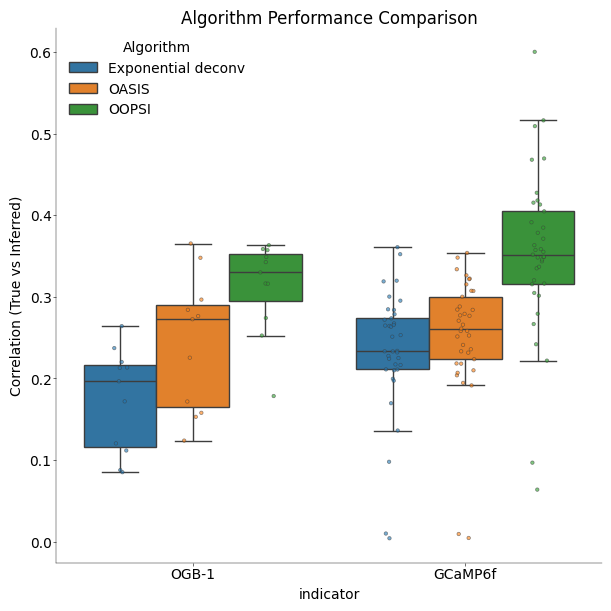

In [ ]:
# ----------------------------------------------------------------------------
# Create Strip and Boxplot for both cells and algorithms Cell as described. (1 pt)
# Describe and explain the results briefly. (1 pt)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")


sns.boxplot(
    data=results_df,
    x="indicator",
    y="correlation",
    hue="algorithm",
    ax=ax,
    fliersize=0,
)

sns.stripplot(
    data=results_df,
    x="indicator",
    y="correlation",
    hue="algorithm",
    dodge=True,
    alpha=0.6,
    ax=ax,
    linewidth=0.5,
    edgecolor="gray",
)


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title="Algorithm")


ax.set_title("Algorithm Performance Comparison")
ax.set_ylabel("Correlation (True vs Inferred)")

The results are clear for both indictators data, that the reconstructed spike trains by the **oopsi** algorithm holds the largets correlation to the ground truth, then the **OASIS** algorithm and finally the simple exponential deconvolution algorithm.